### Using GPR to predict Flame Length

#### Import Libraries

In [1]:
# Sys
import os
import sys
import json 
sys.path.append("..")

# Data
import pandas as pd
import numpy as np
import shap
shap.initjs() 
import joblib
import importlib
from src import path
importlib.reload(path)
from src.path import PATH_DATASETV1, PATH_DATA_FLAMELENGTH, PATH_DATA_FLAMELENGTH_NEW, PATH_FLAMELENGTH_FOLDER

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_validate
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct, RBF

from sklearn.metrics import mean_squared_error, r2_score

# plotting defaults
%matplotlib inline

#### Functions

In [2]:
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))


loo = LeaveOneOut()


def loo_gpr_diagnostics(pipeline, X, y):
    y_pred_loo = np.zeros(len(y), dtype=float)
    y_std_loo = np.zeros(len(y), dtype=float)
    fold_metrics = []

    for fold, (tr, te) in enumerate(loo.split(X, y), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        pipeline.fit(X_tr, y_tr)

        scaler = pipeline.named_steps["scaler"]
        gpr = pipeline.named_steps["gpr"]
        X_tr_scaled = scaler.transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        y_tr_pred = gpr.predict(X_tr_scaled)
        y_te_pred, y_te_std = gpr.predict(X_te_scaled, return_std=True)

        test_idx = te[0]
        test_value = y_te.values[0]
        pred_value = y_te_pred[0]
        std_value = y_te_std[0]
        ci_width = 2 * 1.96 * std_value
        covered = (pred_value - 1.96 * std_value) <= test_value <= (pred_value + 1.96 * std_value)

        y_pred_loo[test_idx] = pred_value
        y_std_loo[test_idx] = std_value

        fold_metrics.append(
            {
                "fold": fold,
                "train_rmse": rmse(y_tr, y_tr_pred),
                "train_r2": r2_score(y_tr, y_tr_pred),
                "test_abs_error": abs(test_value - pred_value),
                "test_coverage_95": 100.0 if covered else 0.0,
                "test_ci_width": ci_width,
            }
        )

    fold_df = pd.DataFrame(fold_metrics)

    return {
        "fold_df": fold_df,
        "y_pred_loo": y_pred_loo,
        "y_std_loo": y_std_loo,
        "test_rmse": rmse(y, y_pred_loo),
        "test_r2": r2_score(y, y_pred_loo),
        "test_abs_error_mean": fold_df["test_abs_error"].mean(),
        "test_abs_error_std": fold_df["test_abs_error"].std(),
        "test_coverage_95_mean": fold_df["test_coverage_95"].mean(),
        "test_coverage_95_std": fold_df["test_coverage_95"].std(),
        "avg_ci_width_mean": fold_df["test_ci_width"].mean(),
        "avg_ci_width_std": fold_df["test_ci_width"].std(),
    }

#### Load and combine FlameLength.xlsx and DatasetV1.xlsx

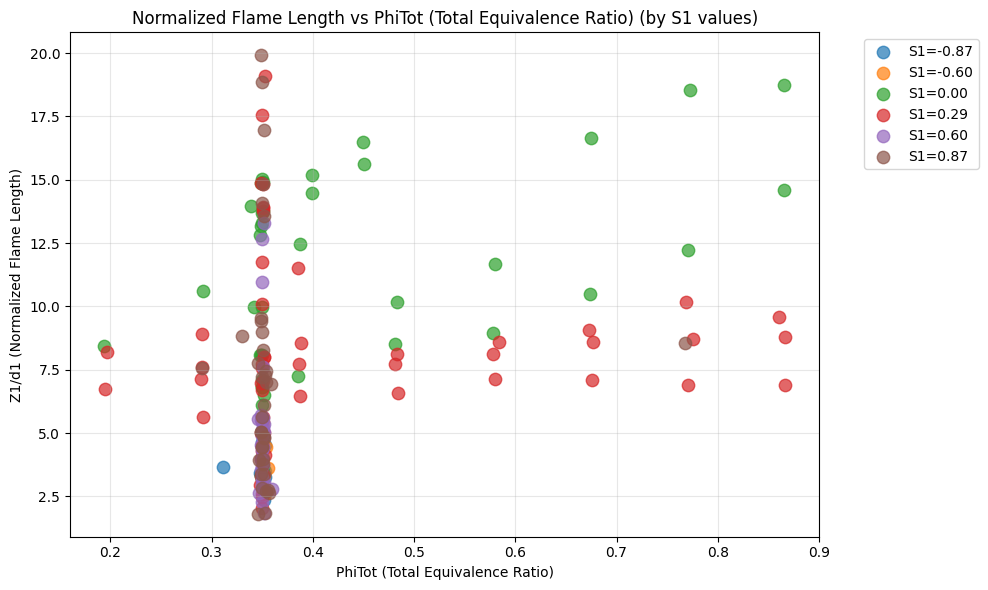

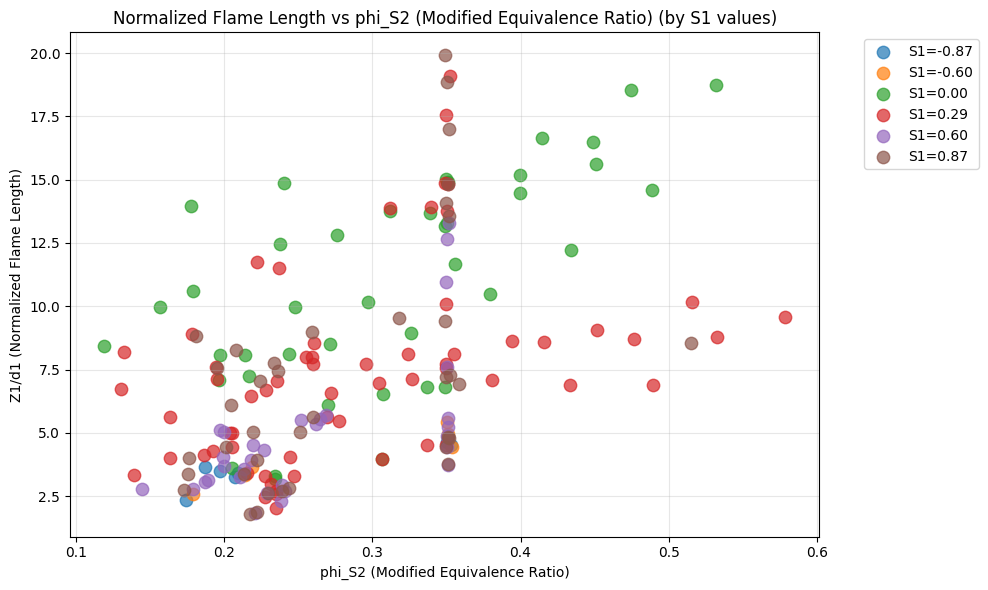

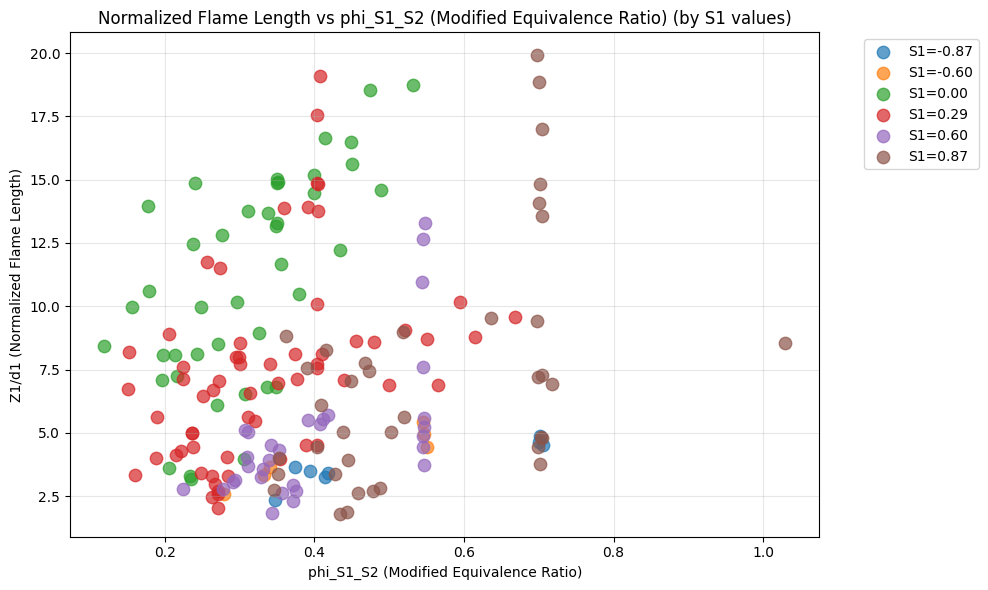

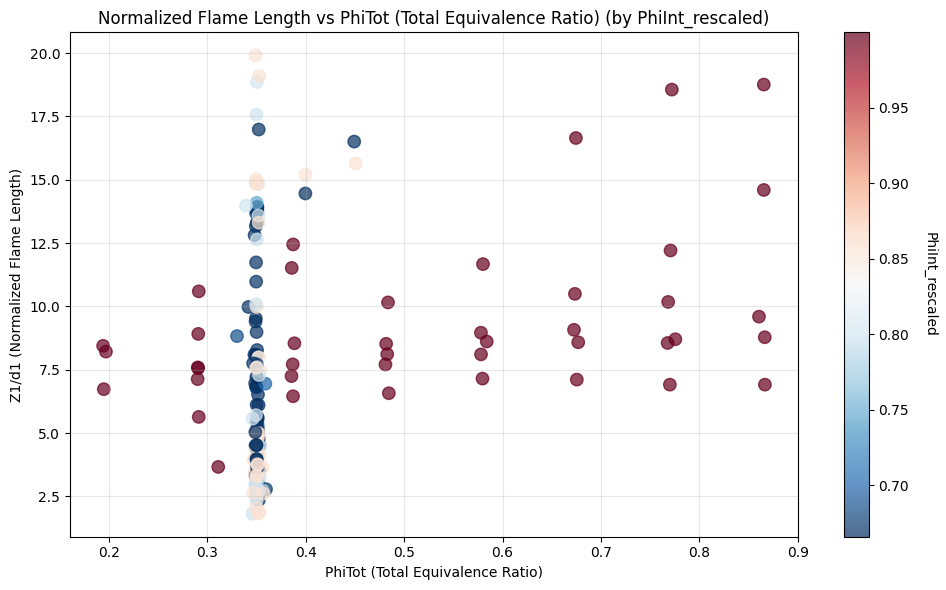

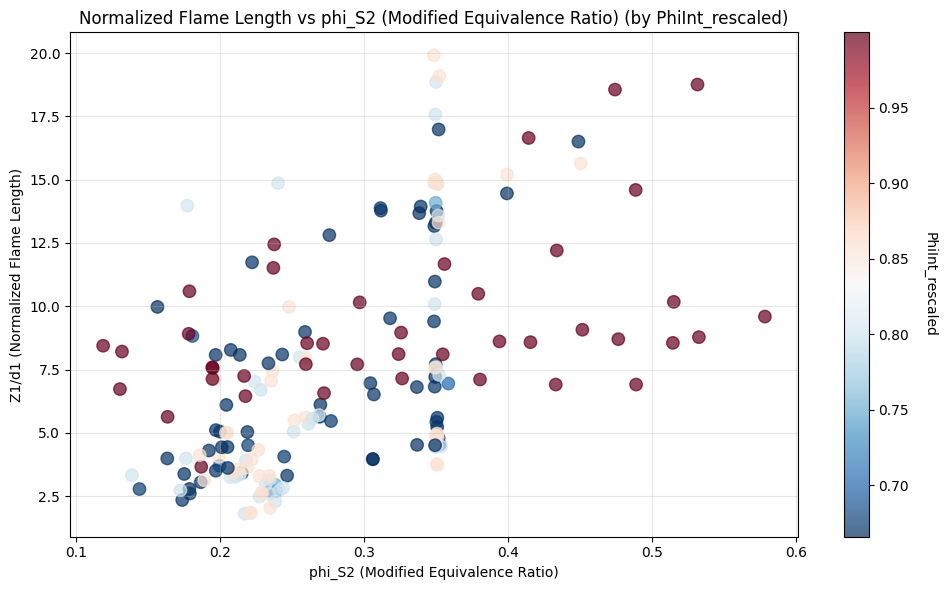

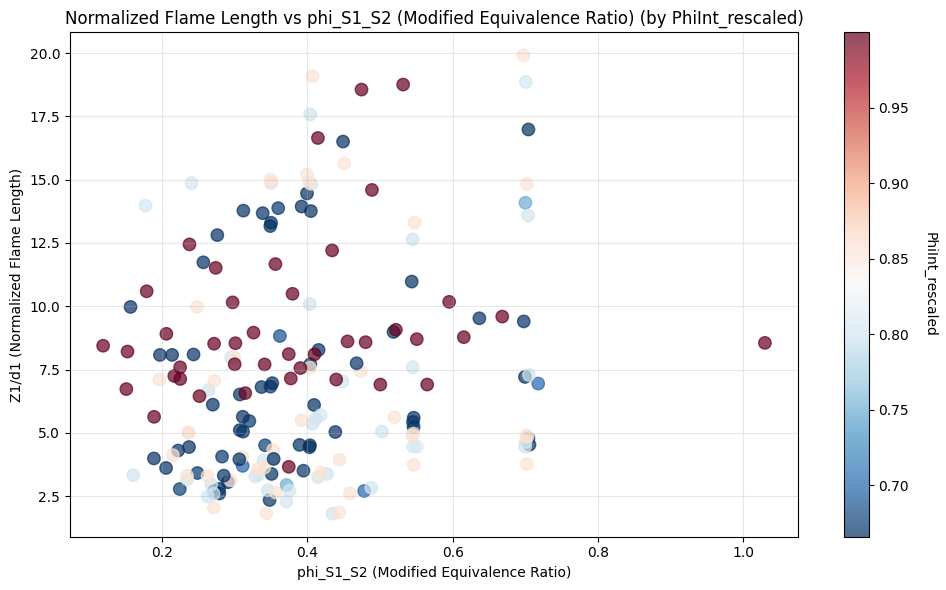

In [3]:
# # OLD - Merging of Datasetv1.xlsx and Flamelength.xlsx

# # Load
# df_main = pd.read_excel(PATH_DATASETV1)
# df_fl = pd.read_excel(PATH_DATA_FLAMELENGTH)

# # Merge on 'Name' column
# df = pd.merge(df_main, df_fl, on="Name")

# # show rows present only in the flame-length file
# # only_in_flame = df_fl[~df_fl['Name'].isin(df_main['Name'])].copy()
# # print(len(only_in_flame), "rows only in flame-length file")
# print(len(df), "rows after merge")

# # display IDs
# # if len(only_in_flame):
# #     display(only_in_flame[['Name']].head(50))
# #     only_in_flame.to_csv(os.path.join(os.path.dirname(PATH_DATA_FLAMELENGTH), "only_in_flame.csv"), index=False)


# # check for duplicates in merged dataframe
# col = "Name"

# print("Any duplicate IDs? ", df[col].duplicated().any())
# print("Duplicate count (extra rows):", df[col].duplicated().sum())

# # drop exact duplicates across all columns, keep first occurrence
# df = df.drop_duplicates(keep="first")
# print("Rows after dropping exact duplicates:", len(df))

# New flame-length data
df = pd.read_excel(PATH_DATA_FLAMELENGTH_NEW)
df["Z1"] /= 1000  # convert mm to m

# Filter for PWR in range [9.5, 10.5]
df = df[(df["PWR"] >= 9.5) & (df["PWR"] <= 10.5)]

# Rescale 'phiint' -> phi/(1+phi) and insert new column immediately after the original
phi = pd.to_numeric(df["PhiInt"], errors="coerce")
phi_rescaled = phi / (1 + phi)
new_col = "PhiInt_rescaled"
idx = df.columns.get_loc("PhiInt")
df.insert(loc=idx + 1, column=new_col, value=phi_rescaled)

# Add S2/S1 ratio
df["S2/S1"] = df["S2"] / (df["S1"] + 0.01)  # avoid division by zero

# Add deltaS
# df["DeltaS"] = np.abs(df["S2"] - df["S1"])
df["DeltaS"] = df["S2"] - df["S1"]

# Convert Type column from Roman numerals to integers
# type_mapping = {"I": 1, "II": 2, "III": 3, "IV": 4}
# df["Type"] = df["Type"].map(type_mapping)

df["DeltaU/u1"] = np.abs(df["u2"] - df["u1"]) / (df["u1"])
df["u1/d1"] = df["u1"] / df["d1"]
df["u1_theta/d1"] = 2 * df["S1"] * df["u1"] / df["d1"]

# Normalise flame length by nozzle diameter
df["Z1/d1"] = df["Z1"] / df["d1"]

df["1/sqrt_J"] = 1 / np.sqrt(df["J"])

df["k"] = 2 / (1 + (df["d1"] / df["d2"]) ** 2)
df["phi_S2"] = df["PhiTot"] * (1 + (df["k"] * df["S2"]) ** 2) ** (-0.5)
df["phi_S1_S2"] = df["PhiTot"] * ((1 + (2 * df["S1"]) ** 2)/(1 + (df["k"] * df["S2"]) ** 2)) ** (0.5)

# Degeneve
df["alpha_degeneve"] = 1 / (1 + df["J"] * (df["d2"] ** 2 - (df["d1"] + 0.002) ** 2) / df["d1"] ** 2) 
df["S12"] = df["d1"]/df["d2"] * df["alpha_degeneve"] * df["S1"] + (1 - df["alpha_degeneve"]) * df["S2"]


# Get unique S1 values and sort them
s1_values = sorted(df["S1"].unique())
# Assign distinct colors to each S1 value
distinct_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
]
s1_colors = distinct_colors[: len(s1_values)]

# Define plots
plot_configs = [
    # ("1/sqrt_J", "1/sqrt(J)"),
    ("PhiTot", "PhiTot (Total Equivalence Ratio)"),
    ("phi_S2", "phi_S2 (Modified Equivalence Ratio)"),
    # ("S2", "S2"),
    ("phi_S1_S2", "phi_S1_S2 (Modified Equivalence Ratio)"),
]

# Plots colored by S1
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    for i, s1_val in enumerate(s1_values):
        mask = df["S1"] == s1_val
        plt.scatter(
            df[mask][x_col],
            df[mask]["Z1/d1"],
            label=f"S1={s1_val:.2f}",
            color=s1_colors[i],
            alpha=0.7,
            s=80,
        )
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by S1 values)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plots colored by PhiInt_rescaled (continuous colormap)
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df[x_col],
        df["Z1/d1"],
        c=df["PhiInt_rescaled"],
        cmap="RdBu_r",
        alpha=0.7,
        s=80,
        vmin=df["PhiInt_rescaled"].min(),
        vmax=df["PhiInt_rescaled"].max(),
    )
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by PhiInt_rescaled)")
    cbar = plt.colorbar(scatter)
    cbar.set_label("PhiInt_rescaled", rotation=270, labelpad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# # Plots colored by phi_S1_S2(continuous colormap)
# for x_col, x_label in plot_configs:
#     plt.figure(figsize=(10, 6))
#     scatter = plt.scatter(
#         df[x_col],
#         df["Z1/d1"],
#         c=df["phi_S1_S2"],
#         cmap="RdBu_r",
#         alpha=0.7,
#         s=80,
#         vmin=df["phi_S1_S2"].min(),
#         vmax=0.7,
#     )
#     plt.xlabel(x_label)
#     plt.ylabel("Z1/d1 (Normalized Flame Length)")
#     plt.title(f"Normalized Flame Length vs {x_label} (by phi_S1_S2)")
#     cbar = plt.colorbar(scatter)
#     cbar.set_label("phi_S1_S2", rotation=270, labelpad=20)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#### Feature Selection

In [4]:
# feature and target selection
features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "d1",
    "d2",
    "u1",
    "u2",
    "Chamber_Binary",
    "DeltaU",
    "u2/u1",
    "S2/S1",
    "DeltaS",
]

features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "PhiTot",
    "u1",
    "u2",
    "d2",
]


target = "Z1/d1"  # FlameLength

X = df[features].copy()
y = df[target].copy()
print("Z1/d1 min:", y.min())
print("Z1/d1 max:", y.max())

print("Feature matrix shape:", X.shape)

Z1/d1 min: 1.8110823616880651
Z1/d1 max: 19.911393917579307
Feature matrix shape: (187, 7)


#### Ridge Baseline - simple linear regression

In [5]:
# Ridge baseline for comparison with GPR
# StandardScaler() normalises features to mean=0, std=1
# alpha is regularization strength
pipeline_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

cv_res = cross_validate(
    pipeline_ridge,
    X,
    y,
    cv=loo,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)
train_rmse = -cv_res["train_score"]

# In LOO, each test fold contains one sample, so fold-wise RMSE equals absolute error.
y_pred_loo = cross_val_predict(pipeline_ridge, X, y, cv=loo, n_jobs=1)
test_abs_error = np.abs(y - y_pred_loo)
test_rmse_loo = rmse(y, y_pred_loo)
test_r2_loo = r2_score(y, y_pred_loo)

print(f"Ridge LOO Train RMSE: mean={train_rmse.mean():.5f}, std={train_rmse.std():.5f}")
print(f"Ridge LOO Test RMSE (aggregated OOF): {test_rmse_loo:.5f}")
print(f"Ridge LOO Test R2 (aggregated OOF): {test_r2_loo:.5f}")
print(f"Ridge LOO Test absolute error: mean={test_abs_error.mean():.5f}, std={test_abs_error.std():.5f}")

Ridge LOO Train RMSE: mean=2.90388, std=0.01668
Ridge LOO Test RMSE (aggregated OOF): 3.04410
Ridge LOO Test R2 (aggregated OOF): 0.50664
Ridge LOO Test absolute error: mean=2.19843, std=2.11124


mean=0.019 : relatively low RMSE   
std=0.003 : small variance across different folds means model is not sensitive to data splits  
R2 not used, misleading with small datasets.

#### Linear Kernel GPR

In [6]:
# GPR with Linear kernel (DotProduct) + WhiteKernel
# DotProduct kernel represents linear relationships: k(x, x') = x · x'
kernel_linear = ConstantKernel(1.0, (1e-2, 1e2)) * DotProduct(
    sigma_0=1.0, sigma_0_bounds=(1e-6, 1e1)
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e-1))
# Pipeline
gpr_linear = GaussianProcessRegressor(
    kernel=kernel_linear, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_linear = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_linear)])

# Aggregated LOO diagnostics with uncertainty + coverage
loo_metrics_linear = loo_gpr_diagnostics(pipeline_gpr_linear, X, y)
fold_df_linear = loo_metrics_linear["fold_df"]

print(
    f"Linear GPR LOO Train RMSE: mean={fold_df_linear.train_rmse.mean():.5f}, std={fold_df_linear.train_rmse.std():.5f}"
)
print(
    f"Linear GPR LOO Train R2 : mean={fold_df_linear.train_r2.mean():.5f}, std={fold_df_linear.train_r2.std():.5f}"
)
print(f"Linear GPR LOO Test RMSE (aggregated OOF): {loo_metrics_linear['test_rmse']:.5f}")
print(f"Linear GPR LOO Test R2 (aggregated OOF): {loo_metrics_linear['test_r2']:.5f}")
print(
    f"Linear GPR LOO Test absolute error: mean={loo_metrics_linear['test_abs_error_mean']:.5f}, std={loo_metrics_linear['test_abs_error_std']:.5f}"
)
print(
    f"Linear GPR LOO Test 95% CI coverage: mean={loo_metrics_linear['test_coverage_95_mean']:.1f}%, std={loo_metrics_linear['test_coverage_95_std']:.1f}%"
)
print(
    f"Linear GPR LOO Avg 95% CI interval width: mean={loo_metrics_linear['avg_ci_width_mean']:.5f}, std={loo_metrics_linear['avg_ci_width_std']:.5f}"
)

# Fit on full data and diagnostics
pipeline_gpr_linear.fit(X, y)
gpr_linear_fitted = pipeline_gpr_linear.named_steps["gpr"]
print("Fitted kernel:", gpr_linear_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_linear_fitted.log_marginal_likelihood_value_)

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the sp

Linear GPR LOO Train RMSE: mean=2.90396, std=0.01673
Linear GPR LOO Train R2 : mean=0.55099, std=0.00364
Linear GPR LOO Test RMSE (aggregated OOF): 3.04251
Linear GPR LOO Test R2 (aggregated OOF): 0.50715
Linear GPR LOO Test absolute error: mean=2.19796, std=2.10941
Linear GPR LOO Test 95% CI coverage: mean=72.2%, std=44.9%
Linear GPR LOO Avg 95% CI interval width: mean=5.47280, std=0.05571
Fitted kernel: 0.252**2 * DotProduct(sigma_0=4.4e-05) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -394.90709099675723


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### RBF Kernel GPR

In [7]:
# GPR with RBF kernel + WhiteKernel
# RBF kernel for smooth non-linear relationships
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(
    length_scale=1.0, length_scale_bounds=(1e-3, 1e3)
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e-1))

gpr_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_rbf = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_rbf)])

# Aggregated LOO diagnostics with uncertainty + coverage (RBF)
loo_metrics_rbf = loo_gpr_diagnostics(pipeline_gpr_rbf, X, y)
fold_df_rbf = loo_metrics_rbf["fold_df"]

print(
    f"RBF GPR LOO Train RMSE: mean={fold_df_rbf.train_rmse.mean():.5f}, std={fold_df_rbf.train_rmse.std():.5f}"
)
print(
    f"RBF GPR LOO Train R2 : mean={fold_df_rbf.train_r2.mean():.5f}, std={fold_df_rbf.train_r2.std():.5f}"
)
print(f"RBF GPR LOO Test RMSE (aggregated OOF): {loo_metrics_rbf['test_rmse']:.5f}")
print(f"RBF GPR LOO Test R2 (aggregated OOF): {loo_metrics_rbf['test_r2']:.5f}")
print(
    f"RBF GPR LOO Test absolute error: mean={loo_metrics_rbf['test_abs_error_mean']:.5f}, std={loo_metrics_rbf['test_abs_error_std']:.5f}"
)
print(
    f"RBF GPR LOO Test 95% CI coverage: mean={loo_metrics_rbf['test_coverage_95_mean']:.1f}%, std={loo_metrics_rbf['test_coverage_95_std']:.1f}%"
)
print(
    f"RBF GPR LOO Avg 95% CI interval width: mean={loo_metrics_rbf['avg_ci_width_mean']:.5f}, std={loo_metrics_rbf['avg_ci_width_std']:.5f}"
)

# Fit on full data and diagnostics
pipeline_gpr_rbf.fit(X, y)
gpr_rbf_fitted = pipeline_gpr_rbf.named_steps["gpr"]
print("Fitted kernel:", gpr_rbf_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_rbf_fitted.log_marginal_likelihood_value_)

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the

RBF GPR LOO Train RMSE: mean=1.11976, std=0.68790
RBF GPR LOO Train R2 : mean=0.90816, std=0.05655
RBF GPR LOO Test RMSE (aggregated OOF): 3.41126
RBF GPR LOO Test R2 (aggregated OOF): 0.38045
RBF GPR LOO Test absolute error: mean=2.23295, std=2.58581
RBF GPR LOO Test 95% CI coverage: mean=91.4%, std=28.0%
RBF GPR LOO Avg 95% CI interval width: mean=10.20475, std=4.23539
Fitted kernel: 0.99**2 * RBF(length_scale=0.931) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -236.05247765314797


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### Linear + RBF Kernel GPR

In [8]:
# GPR with Linear + RBF kernel + WhiteKernel
# Combines linear and non-linear relationships
kernel_combined = ConstantKernel(1.0, (1e-2, 1e2)) * (
    DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-8, 1e-1))
    + RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3))
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e-1))

gpr_combined = GaussianProcessRegressor(
    kernel=kernel_combined, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_combined = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_combined)])

# Aggregated LOO diagnostics with uncertainty + coverage
loo_metrics_combined = loo_gpr_diagnostics(pipeline_gpr_combined, X, y)
fold_df_combined = loo_metrics_combined["fold_df"]

print(
    f"Linear+RBF GPR LOO Train RMSE: mean={fold_df_combined.train_rmse.mean():.5f}, std={fold_df_combined.train_rmse.std():.5f}"
)
print(
    f"Linear+RBF GPR LOO Train R2 : mean={fold_df_combined.train_r2.mean():.5f}, std={fold_df_combined.train_r2.std():.5f}"
)
print(f"Linear+RBF GPR LOO Test RMSE (aggregated OOF): {loo_metrics_combined['test_rmse']:.5f}")
print(f"Linear+RBF GPR LOO Test R2 (aggregated OOF): {loo_metrics_combined['test_r2']:.5f}")
print(
    f"Linear+RBF GPR LOO Test absolute error: mean={loo_metrics_combined['test_abs_error_mean']:.5f}, std={loo_metrics_combined['test_abs_error_std']:.5f}"
)
print(
    f"Linear+RBF GPR LOO Test 95% CI coverage: mean={loo_metrics_combined['test_coverage_95_mean']:.1f}%, std={loo_metrics_combined['test_coverage_95_std']:.1f}%"
)
print(
    f"Linear+RBF GPR LOO Avg 95% CI interval width: mean={loo_metrics_combined['avg_ci_width_mean']:.5f}, std={loo_metrics_combined['avg_ci_width_std']:.5f}"
)

# Fit on full data and diagnostics
pipeline_gpr_combined.fit(X, y)
gpr_combined_fitted = pipeline_gpr_combined.named_steps["gpr"]
print("Fitted kernel:", gpr_combined_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_combined_fitted.log_marginal_likelihood_value_)

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the sp

Linear+RBF GPR LOO Train RMSE: mean=0.64647, std=0.00343
Linear+RBF GPR LOO Train R2 : mean=0.97775, std=0.00018
Linear+RBF GPR LOO Test RMSE (aggregated OOF): 3.04901
Linear+RBF GPR LOO Test R2 (aggregated OOF): 0.50505
Linear+RBF GPR LOO Test absolute error: mean=2.19288, std=2.12411
Linear+RBF GPR LOO Test 95% CI coverage: mean=94.1%, std=23.6%
Linear+RBF GPR LOO Avg 95% CI interval width: mean=11.55389, std=0.37644
Fitted kernel: 0.591**2 * DotProduct(sigma_0=4.33e-08) + RBF(length_scale=0.00881) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -206.3278215413134


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### Matern Kernel GPR

In [9]:
# GPR with Matern (ARD) + WhiteKernel; use ARD by passing a vector length_scale
kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e8), nu=2.5
) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e-1))

gpr_matern = GaussianProcessRegressor(
    kernel=kernel_matern, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_matern = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_matern)])

# Aggregated LOO diagnostics with uncertainty + coverage
loo_metrics_matern = loo_gpr_diagnostics(pipeline_gpr_matern, X, y)
fold_df_matern = loo_metrics_matern["fold_df"]

print(
    f"Matern GPR LOO Train RMSE: mean={fold_df_matern.train_rmse.mean():.5f}, std={fold_df_matern.train_rmse.std():.5f}"
)
print(
    f"Matern GPR LOO Train R2 : mean={fold_df_matern.train_r2.mean():.5f}, std={fold_df_matern.train_r2.std():.5f}"
)
print(f"Matern GPR LOO Test RMSE (aggregated OOF): {loo_metrics_matern['test_rmse']:.5f}")
print(f"Matern GPR LOO Test R2 (aggregated OOF): {loo_metrics_matern['test_r2']:.5f}")
print(
    f"Matern GPR LOO Test absolute error: mean={loo_metrics_matern['test_abs_error_mean']:.5f}, std={loo_metrics_matern['test_abs_error_std']:.5f}"
)
print(
    f"Matern GPR LOO Test 95% CI coverage: mean={loo_metrics_matern['test_coverage_95_mean']:.1f}%, std={loo_metrics_matern['test_coverage_95_std']:.1f}%"
)
print(
    f"Matern GPR LOO Avg 95% CI interval width: mean={loo_metrics_matern['avg_ci_width_mean']:.5f}, std={loo_metrics_matern['avg_ci_width_std']:.5f}"
)

# Fit on full data and diagnostics
pipeline_gpr_matern.fit(X, y)
gpr_matern_fitted = pipeline_gpr_matern.named_steps["gpr"]
print("Fitted kernel:", gpr_matern_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_matern_fitted.log_marginal_likelihood_value_)

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the sp

Matern GPR LOO Train RMSE: mean=1.41708, std=0.52460
Matern GPR LOO Train R2 : mean=0.87850, std=0.05056
Matern GPR LOO Test RMSE (aggregated OOF): 2.77883
Matern GPR LOO Test R2 (aggregated OOF): 0.58888
Matern GPR LOO Test absolute error: mean=1.68885, std=2.21267
Matern GPR LOO Test 95% CI coverage: mean=89.3%, std=31.0%
Matern GPR LOO Avg 95% CI interval width: mean=7.56929, std=2.68602
Fitted kernel: 0.907**2 * Matern(length_scale=[3.88, 0.657, 1.4, 4.45, 8.5e+03, 1.54, 2.45], nu=2.5) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -206.2990186214276


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### File saving

In [10]:
# save cleaned merged data and trained pipeline
# out_csv = os.path.join(PATH_FLAMELENGTH_FOLDER, "merged_cleaned_with_flame.csv")
# df.to_csv(out_csv, index=False)
# print("Saved merged data to", out_csv)

# # model_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "gpr_pipeline_matern.joblib")
# # joblib.dump(pipeline_gpr_matern, model_path)
# # print("Saved Matern GPR pipeline to", model_path)

#### Analysis Matern

ExactExplainer explainer: 188it [00:10,  1.44it/s]                         


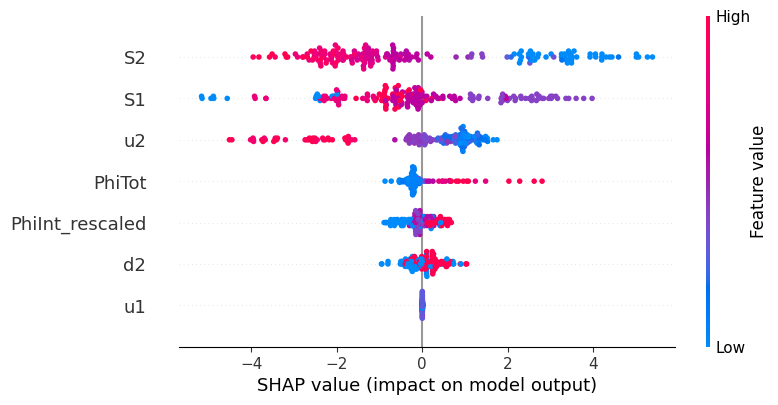

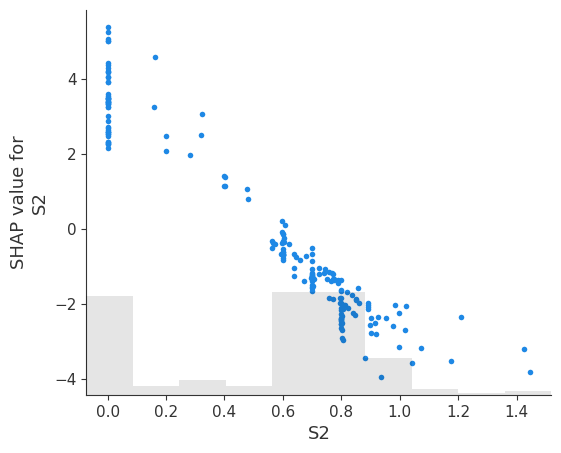

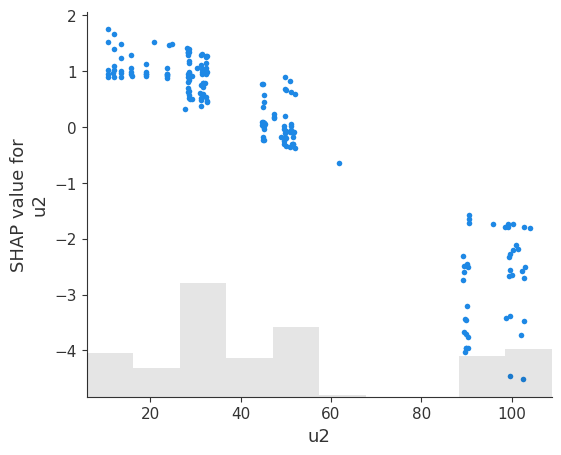

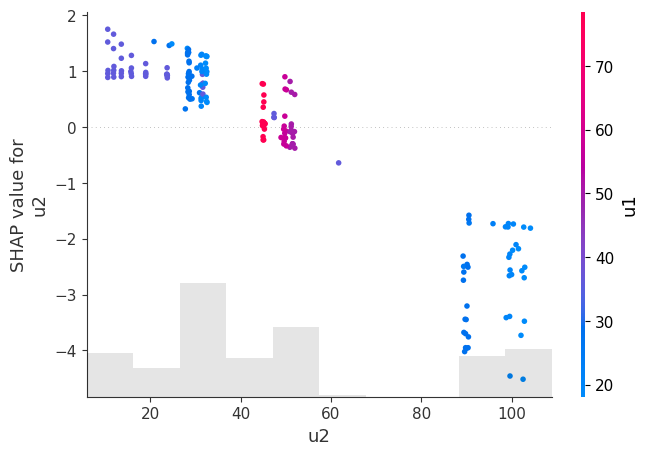

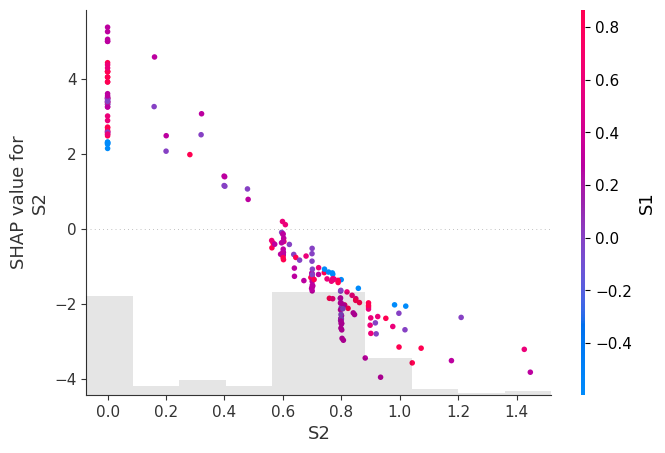

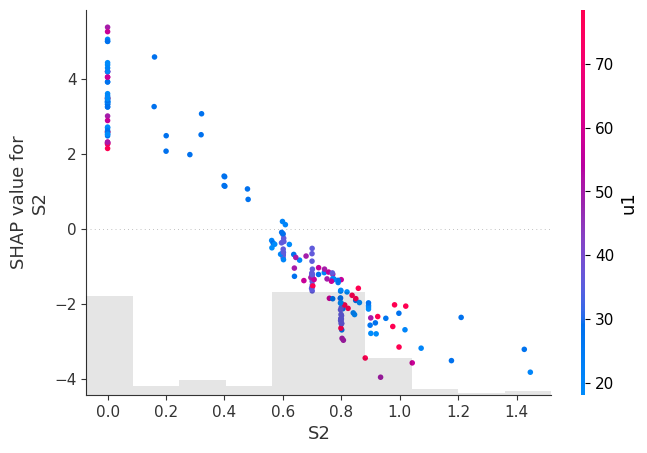

In [11]:
# model = callable that predicts with the full pipeline
model = lambda X_in: pipeline_gpr_matern.predict(pd.DataFrame(X_in, columns=X.columns))

# use DataFrames to preserve feature names
X_bg_df = X.sample(n=min(50, len(X)), random_state=42)
X_explain_df = X.sample(n=min(200, len(X)), random_state=24)

explainer = shap.Explainer(model, X_bg_df)  # KernelExplainer under the hood
shap_values = explainer(X_explain_df)

shap.plots.beeswarm(shap_values, max_display=20)
# shap.plots.bar(shap_values)
shap.plots.scatter(shap_values[:, "S2"])
shap.plots.scatter(shap_values[:, "u2"])

# Dependence plots
shap.plots.scatter(shap_values[:, "u2"], color=shap_values[:, "u1"])
# shap.plots.scatter(shap_values[:, "u2"], color=shap_values[:, "d2"])
shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "S1"])
# shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "d2"])
shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "u1"])

In [12]:
shap.plots.force(shap_values)